# 02 · Your First RNN in PyTorch — Shapes, the Training Loop, and Learning to Predict a Signal

In notebook 01 we built an RNN by hand and ran it forward with **random, untrained** weights.
Now we let a network **learn** its weights from data.

Goals of this notebook:

1. **Decode tensor shapes** — the `(batch, time, features)` convention that confuses everyone at
   first. This is the #1 source of RNN bugs, so we spend real time here.
2. Build the **exact same RNN two ways**:
   - `nn.RNNCell` inside a manual `for`-loop over time (you *see* every step — mirrors notebook 01),
   - `nn.RNN`, PyTorch's batched, optimized version (what you use in practice).
3. Train a **many-to-one** model: read a window of a sine wave and **predict the next value**.
4. Understand the **training loop** (forward → loss → backward → step) and visualize the result.

> 🧭 We use a sine wave on purpose: it's the "hello world" of sequence modeling. It has clear
> structure the RNN can learn, and we can *see* whether predictions are good just by looking.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# Everything here runs comfortably on CPU. We keep a device variable so the same code would use a
# GPU automatically if you ever run it on one.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.10.0+cpu | device: cpu


## 1. The three-dimensional tensor: `(batch, time, features)`

An RNN in PyTorch expects a **3-D tensor**. Every RNN bug you will ever have starts with getting
these three axes wrong, so let's nail them down:

| Axis | Name | "How many..." | In our sine example |
|---|---|---|---|
| 0 | **batch** | ...independent sequences do we process at once? | e.g. 64 windows |
| 1 | **time** (sequence length) | ...steps are in each sequence? | 20 past points |
| 2 | **features** | ...numbers describe each single time step? | 1 (just the value) |

So a batch of 64 windows, each 20 steps long, each step a single number, is shaped
`(64, 20, 1)`.

> ⚠️ **`batch_first`** — By default PyTorch's `nn.RNN` expects `(time, batch, features)`. That
> ordering is unintuitive, so we always pass **`batch_first=True`** to get the friendlier
> `(batch, time, features)`. Remember this flag; forgetting it is a classic silent bug.

- **Features > 1** means *multivariate* sequences — e.g. a sensor step is `[voltage, current,
  temperature]` → features = 3. We'll do a multivariate example in notebook 06.

In [40]:
# Let's make the shapes concrete with a dummy batch, then push it through an RNN once.
batch, time_steps, features = 4, 20, 1 # this means 4 sequences, each of length 20, with 1 feature per time step
dummy = torch.randn(batch, time_steps, features)
print("dummy input shape (batch, time, features):", tuple(dummy.shape))

demo_rnn = nn.RNN(input_size=features, hidden_size=8, batch_first=True)
h_out, h_n = demo_rnn(dummy)
# h_out  : hidden state at EVERY time step -> (batch, time, hidden)
# h_n  : hidden state at the LAST time step only -> (num_layers, batch, hidden)
# the number of layers is 1 here, so h_n has shape (1, batch, hidden). 
# If we had multiple layers, h_n would contain the last hidden state for each layer.
# The number of layers is set by the `num_layers` argument when creating the RNN. The default is 1.
print("h_out  shape (batch, time, hidden) :", tuple(h_out.shape), " <- one memory vector per step")
print("h_n  shape (layers, batch, hidden):", tuple(h_n.shape), " <- the final memory only")
print("\nSanity check: h_out[:, -1, :] equals h_n[-1] ?",
      torch.allclose(h_out[:, -1, :], h_n[-1]))
print("(Yes — the last column of `h_out` IS the final hidden state. Handy for many-to-one.)")

dummy input shape (batch, time, features): (4, 20, 1)
h_out  shape (batch, time, hidden) : (4, 20, 8)  <- one memory vector per step
h_n  shape (layers, batch, hidden): (1, 4, 8)  <- the final memory only

Sanity check: h_out[:, -1, :] equals h_n[-1] ? True
(Yes — the last column of `h_out` IS the final hidden state. Handy for many-to-one.)


## 2. Make the data: sliding windows over a sine wave

We want a **many-to-one** setup: given the last `window` values, predict the **next** one.

The standard trick to turn one long time series into many training examples is a **sliding
window**: slide a fixed-length window across the series; the window is the input `X` and the value
just after it is the target `y`. We'll add a little noise so the task isn't trivially easy.

X shape (samples, time, features): (570, 30, 1)
y shape (samples, 1)            : (570, 1)

train samples: 456 | test samples: 114


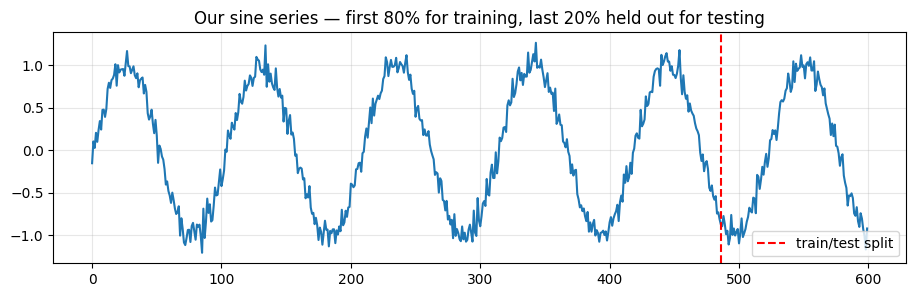

In [16]:
# 1) create one long, slightly noisy sine wave
T = 600 # number of time steps
t = np.arange(T)
series = np.sin(0.06 * t) + 0.1 * np.random.randn(T)   # signal + noise

# 2) slide a window across it to build (X, y) pairs, also called sequence length
WINDOW = 30   # how many past steps the model sees

def make_windows(series, window):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i : i + window])   # the past `window` values  -> input sequence
        y.append(series[i + window])       # the very next value       -> target
    X = np.array(X)[..., None]             # add the feature axis -> (num_samples, window, 1)
    y = np.array(y)[:, None]               # -> (num_samples, 1)
    return X.astype(np.float32), y.astype(np.float32)

X, y = make_windows(series, WINDOW)
print("X shape (samples, time, features):", X.shape)
print("y shape (samples, 1)            :", y.shape)

# 3) split by TIME (never shuffle a time series before splitting — that leaks the future!)
split = int(0.8 * len(X))
X_train, y_train = torch.tensor(X[:split]), torch.tensor(y[:split])
X_test,  y_test  = torch.tensor(X[split:]), torch.tensor(y[split:])
print(f"\ntrain samples: {len(X_train)} | test samples: {len(X_test)}")

plt.figure(figsize=(11, 3))
plt.plot(series)
plt.axvline(split + WINDOW, color="red", ls="--", label="train/test split")
plt.title("Our sine series — first 80% for training, last 20% held out for testing")
plt.legend(); plt.grid(alpha=0.3); plt.show()

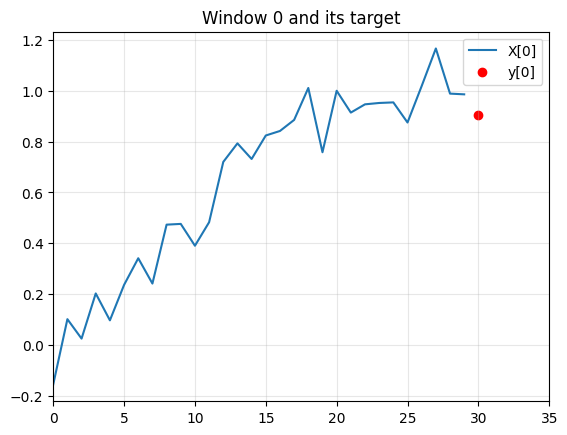

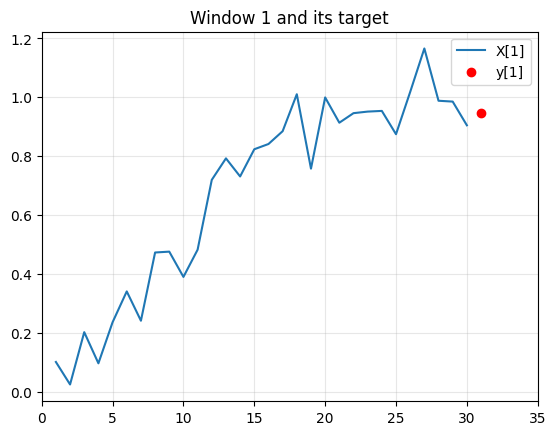

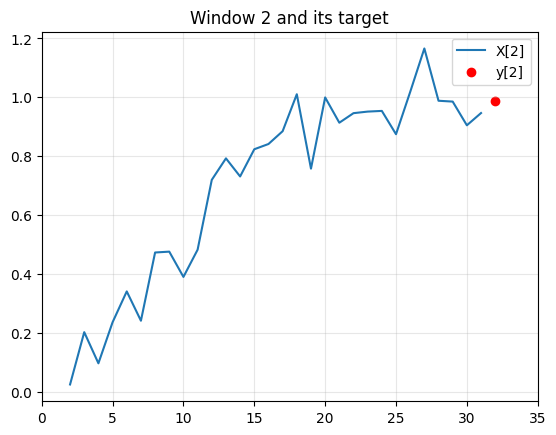

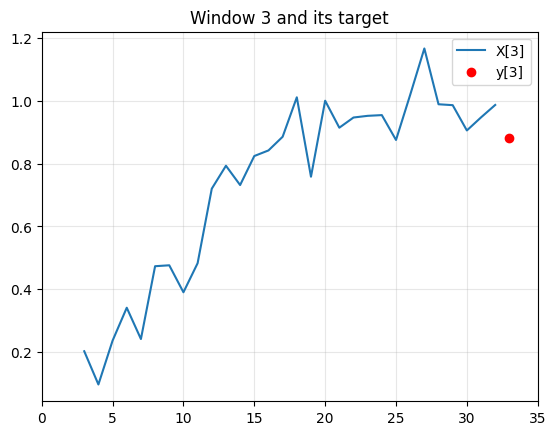

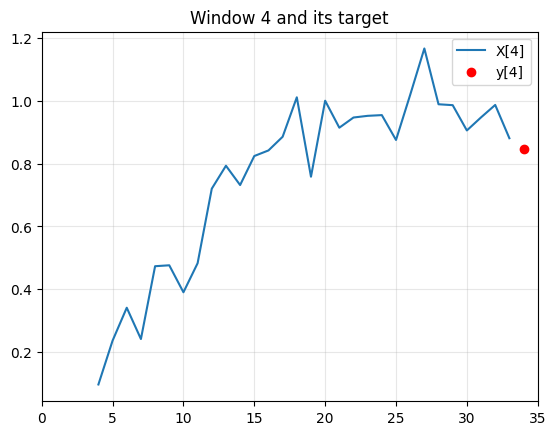

In [31]:
X, y = make_windows(series, WINDOW)
# visualize the first 5 windows and their targets
for i in range(5):
    x_points = np.arange(i, i + WINDOW)
    plt.plot(x_points, X[i], label=f"X[{i}]")
    plt.scatter(i + WINDOW, y[i], color="red", label=f"y[{i}]")
    plt.title(f"Window {i} and its target")
    # set xlim to 0
    plt.xlim(0, 5 + WINDOW)
    plt.legend(); plt.grid(alpha=0.3); plt.show()

> 🔑 **Why split by time, not randomly?** In forecasting, using future points to train and past
> points to test would leak information the model won't have in reality ("look-ahead bias"). We
> always keep the test set *strictly after* the training set in time. This is one of the most
> common (and costly) mistakes in real forecasting projects.

## 3. Version A — a manual loop with `nn.RNNCell` (to *see* the flow)

`nn.RNNCell` processes **one time step**. We drive it with our own `for`-loop over the time axis,
exactly like the NumPy `forward` method in notebook 01 — except now the weights are `nn.Parameter`s
that PyTorch will train for us via autograd.

This version is not how you'd write production code, but it makes the **many-to-one** pattern
crystal clear: loop over all steps, then use the **final hidden state** to make one prediction.

### What does nn.RNNCell actually compute, and how is it different from nn.Linear?

nn.Linear is a single stateless affine map:

$$y = W x + b$$

One input in, one output out. No memory, no nonlinearity, no notion of "previous step."

nn.RNNCell computes (straight from the PyTorch docs):

$$h' = \tanh\big(W_{ih}, x + b_{ih} ;+; W_{hh}, h + b_{hh}\big)$$

Notice it takes two inputs — the current input x and the previous hidden state h — and returns the new hidden state h'. So mechanically: 

RNNCell(x, h)  ==  tanh( Linear_input(x) + Linear_hidden(h) )

It's essentially two Linear layers summed, then a tanh:

- W_ih = a Linear on the input (like your Linear example),
- W_hh = a second Linear on the previous hidden state — this is the recurrent connection, the part Linear doesn't have,
add them, apply tanh.

The three differences that matter:

1. State / recurrence. Linear has no h. RNNCell takes h in and produces the next h — it's designed to be called in a loop, feeding its own output back (which is exactly what ManualRNN.forward does with for step in range(T): h = self.cell(x[:, step, :], h)).
2. The extra weight matrix W_hh. This hidden-to-hidden map is what lets information persist through time — the whole point of an RNN.
3. The nonlinearity. RNNCell bakes in tanh (or relu if you pass nonlinearity='relu'); Linear is purely linear.

The forward algorithm will be:

Execute the RNNcell T (time steps) times:
$$ h_t = \tanh\!\big(W_{xh}\, x_t \;+\; W_{hh}\, h_{t-1} \;+\; b_h\big) $$

and, when we want a prediction at that step, map the final memory using Linear:
$$ y_t = W_{hy}\, h_t + b_y $$

In [32]:
class ManualRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=16):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = nn.RNNCell(input_size, hidden_size)  # ONE step of recurrence
        self.head = nn.Linear(hidden_size, 1)            # map final memory -> a single number

    def forward(self, x):                 # x: (batch, time, features)
        b, T, _ = x.shape # b = batch size, T = time steps
        h = torch.zeros(b, self.hidden_size, device=x.device)  # h_0: empty memory
        for step in range(T):             # <-- explicit loop over TIME
            h = self.cell(x[:, step, :], h)   # feed step `step` and the previous memory back in
        # after the loop, `h` is the memory summarizing the WHOLE window -> predict next value
        return self.head(h)

manual_model = ManualRNN().to(device)
print(manual_model)
print("\nA forward pass on one batch gives shape:",
      tuple(manual_model(X_train[:5].to(device)).shape), "(5 predictions, one per window)")

ManualRNN(
  (cell): RNNCell(1, 16)
  (head): Linear(in_features=16, out_features=1, bias=True)
)

A forward pass on one batch gives shape: (5, 1) (5 predictions, one per window)


## 4. The training loop — the four steps you'll repeat forever

Every PyTorch training step is the same four-beat rhythm. Memorize this rhythm; it never changes:

1. **Forward** — run inputs through the model to get predictions.
2. **Loss** — measure how wrong the predictions are (here: Mean Squared Error, good for regression).
3. **Backward** — `loss.backward()` computes gradients via **Back-Prop Through Time**.
4. **Step** — the optimizer nudges every weight a little to reduce the loss; then zero the
   gradients for next time.

We wrap it in a reusable `train()` function so we can reuse it for the second model version too.

In [37]:
X_train.shape # shape = (number of samples, window/sequence_length, features) 

torch.Size([456, 30, 1])

In [39]:
def train(model, X_train, y_train, epochs=200, lr=0.01, verbose=True):
    model.to(device)
    X_train, y_train = X_train.to(device), y_train.to(device)
    loss_fn = nn.MSELoss() # it is a regression problem -> mean squared error
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # Adam: a solid default optimizer
    history = []
    for epoch in range(epochs): # we dont use batches here, for simplicity.
        model.train()
        optimizer.zero_grad()          # (4b) clear old gradients
        pred = model(X_train)          # (1) forward, using the whole training set as one batch (not recommended for large datasets)
        loss = loss_fn(pred, y_train)  # (2) loss
        loss.backward()                # (3) backward  (Back-Prop Through Time happens here)
        optimizer.step()               # (4a) update weights
        history.append(loss.item())
        if verbose and (epoch + 1) % 40 == 0:
            print(f"  epoch {epoch+1:3d} | train MSE = {loss.item():.4f}")
    return history

print("Training the manual RNNCell model:")
hist_manual = train(manual_model, X_train, y_train, epochs=200)

Training the manual RNNCell model:
  epoch  40 | train MSE = 0.0157
  epoch  80 | train MSE = 0.0149
  epoch 120 | train MSE = 0.0137
  epoch 160 | train MSE = 0.0130
  epoch 200 | train MSE = 0.0118


## 5. Version B — the batched `nn.RNN` (what you actually use)

`nn.RNN` does the same time loop **internally in optimized C++**, so it's faster and shorter to
write. For a **many-to-one** task we take the hidden state at the **last time step**
(`h_out[:, -1, :]`) and feed it to a linear head.

Compare the two `forward` methods — they express the *same idea*, but `nn.RNN` hides the loop.

Training the batched nn.RNN model:
  epoch  40 | train MSE = 0.0167
  epoch  80 | train MSE = 0.0151
  epoch 120 | train MSE = 0.0139
  epoch 160 | train MSE = 0.0130
  epoch 200 | train MSE = 0.0130


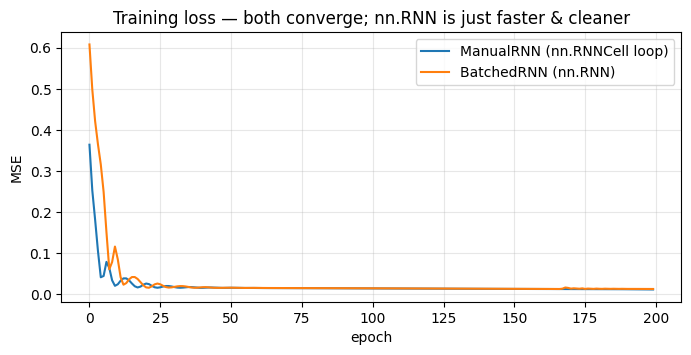

In [60]:
class BatchedRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, num_layers=1):
        super().__init__()
        # batch_first=True means the input and output tensors are provided as (batch, time, features)
        #  instead of (time, batch, features)
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):                # x: (batch, time, features)
        # the way RNN knows how many time steps to unroll for is determined 
        # by the second dimension of the input tensor `x`. The loop over time
        # steps is handled internally by the `nn.RNN` module, so you don't need 
        # to explicitly write a loop in your forward method.
        h_out, h_n = self.rnn(x)           # h_out: (batch, time, hidden) — the loop runs inside here
        last = h_out[:, -1, :]             # take the LAST step's memory -> many-to-one
        return self.head(last)

batched_model = BatchedRNN().to(device)
print("Training the batched nn.RNN model:")
hist_batched = train(batched_model, X_train, y_train, epochs=200)

plt.figure(figsize=(8, 3.5))
plt.plot(hist_manual, label="ManualRNN (nn.RNNCell loop)")
plt.plot(hist_batched, label="BatchedRNN (nn.RNN)")
plt.title("Training loss — both converge; nn.RNN is just faster & cleaner")
plt.xlabel("epoch"); plt.ylabel("MSE"); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 6. Evaluate: does it predict the held-out future?

The real test is the **last 20%** of the series, which the model never saw during training. We
predict each test window and overlay predictions on the truth. We also compare against a
**naive baseline** — "tomorrow = today" (predict the last value of the window). Beating the naive
baseline is the honest bar every forecasting model must clear.

RNN   test RMSE : 0.1115
Naive test RMSE : 0.1354  (predict last value)
Lower is better — the RNN should beat the naive baseline.


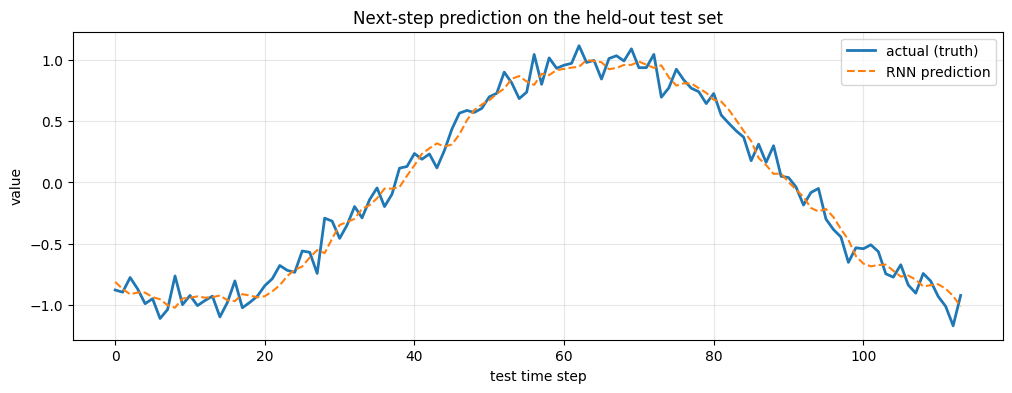

In [61]:
def rmse(a, b):
    return float(torch.sqrt(torch.mean((a - b) ** 2)))

batched_model.eval()
with torch.no_grad():                                  # no gradients needed at inference -> faster
    pred_test = batched_model(X_test.to(device)).cpu()

# naive baseline: predict the LAST value in each input window
naive_pred = X_test[:, -1, :]

print(f"RNN   test RMSE : {rmse(pred_test, y_test):.4f}")
print(f"Naive test RMSE : {rmse(naive_pred, y_test):.4f}  (predict last value)")
print("Lower is better — the RNN should beat the naive baseline.")

plt.figure(figsize=(12, 4))
plt.plot(y_test.numpy(), label="actual (truth)", lw=2)
plt.plot(pred_test.numpy(), label="RNN prediction", ls="--")
plt.title("Next-step prediction on the held-out test set")
plt.xlabel("test time step"); plt.ylabel("value"); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 7. Bonus intuition: multi-step "rollout" forecasting

So far we predict **one** step ahead. What if a client asks for the **next 60 steps**? A common
approach is a **recursive rollout**: predict one step, append it to the window, drop the oldest
value, and predict again — feeding the model *its own predictions*.

This is powerful but be warned: **errors compound**. Each small mistake feeds the next
prediction, so accuracy decays the further out you go. (In notebook 06 we'll meet a cleaner
alternative — a seq2seq model that outputs the whole horizon at once.)

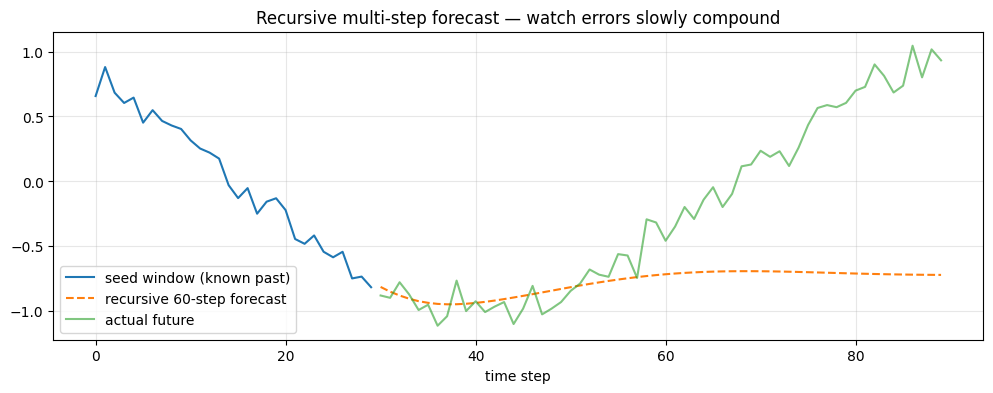

In [62]:
def recursive_forecast(model, seed_window, n_steps):
    '''Forecast `n_steps` into the future by feeding predictions back in.'''
    model.eval()
    window = seed_window.clone()                 # shape (1, WINDOW, 1)
    preds = []
    with torch.no_grad():
        for _ in range(n_steps):
            nxt = model(window.to(device)).cpu() # predict one step: (1, 1)
            preds.append(nxt.item())
            nxt = nxt.view(1, 1, 1) # reshape to (1, 1, 1) so we can concatenate it to the window
            window_1 = window[:, 1:, :]  # drop the oldest value
            window = torch.cat([window_1, nxt], dim=1) # slide window forward adding the new prediction
    return np.array(preds)

seed = X_test[:1]                                # start from the first test window
future = recursive_forecast(batched_model, seed, n_steps=60)

plt.figure(figsize=(12, 4))
plt.plot(range(WINDOW), seed.numpy().ravel(), label="seed window (known past)")
plt.plot(range(WINDOW, WINDOW + 60), future, label="recursive 60-step forecast", ls="--")
plt.plot(range(WINDOW, WINDOW + 60), y_test.numpy().ravel()[:60], label="actual future", alpha=0.6)
plt.title("Recursive multi-step forecast — watch errors slowly compound")
plt.xlabel("time step"); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 8. Recap & what's next

You now can:

- Shape data as **`(batch, time, features)`** and remember **`batch_first=True`**.
- Build a many-to-one RNN two ways: a **manual `nn.RNNCell` loop** and the batched **`nn.RNN`**,
  and see they express the same recurrence.
- Run the universal **forward → loss → backward → step** training loop.
- **Split time series by time**, evaluate against a **naive baseline**, and do a recursive
  multi-step rollout.

**But vanilla RNNs have a serious weakness:** they struggle to remember things over **long**
sequences because gradients *vanish* as they flow back through many time steps. That's exactly the
problem **LSTM** and **GRU** were invented to solve.

➡️ **Next:** `03_lstm_gru.ipynb` — the vanishing-gradient problem shown concretely, then LSTM &
GRU gates explained and compared on a task a vanilla RNN simply *cannot* learn.